In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from random import choices
from sklearn.metrics import f1_score, balanced_accuracy_score
from tqdm import tqdm

In [2]:
demographics = [
        "age",
        "gender",
        "religion",
        "ethnicity",
        "employment_status",
        "education",
        "birth_region",
        "reside_region",
        "marital_status",
        "english_proficiency",
    ]

In [3]:
olmo_answers = pd.read_pickle("results/OLMo-2-1124-7B-Instruct_answers.gz", compression="gzip")

for df in [olmo_answers]:
    df["answer_correct"] = 1*(df["answer"] == df["gold_answer"])
    df["answer_no"] = 1*(df["answer"] == "no")

In [4]:
baselines = {}
for demographic in tqdm(demographics):
    baselines[demographic] = {}
    options = olmo_answers[demographic].unique()
    true_answers = olmo_answers[demographic].tolist()
    random_answers = choices(options,k=len(true_answers))
    majority_answers = [olmo_answers[demographic].value_counts().reset_index().iloc[0][demographic]]*len(true_answers)
    baselines[demographic]["random_micro"] = f1_score(true_answers, random_answers, average="micro")
    baselines[demographic]["random_macro"] = f1_score(true_answers, random_answers, average="macro")
    baselines[demographic]["random_weighted"] = f1_score(true_answers, random_answers, average="weighted")
    baselines[demographic]["random_balancedacc"] = balanced_accuracy_score(true_answers, random_answers)
    baselines[demographic]["majority_micro"] = f1_score(true_answers, majority_answers, average="micro")
    baselines[demographic]["majority_macro"] = f1_score(true_answers, majority_answers, average="macro")
    baselines[demographic]["majority_weighted"] = f1_score(true_answers, majority_answers, average="weighted")
    baselines[demographic]["majority_balancedacc"] = balanced_accuracy_score(true_answers, majority_answers)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:37<00:00,  9.72s/it]


In [142]:
olmo_answers = olmo_answers.melt(id_vars=['conversation_id', 'user_id', 'conversation_type', 'opening_prompt',
       'conversation_turns', 'conversation_history', 'performance_attributes',
       'choice_attributes', 'open_feedback', 'generated_datetime_x',
       'timing_duration_s_x', 'timing_duration_mins_x',
       'included_in_balanced_subset_x', 'survey_only',
       'num_completed_conversations', 'consent', 'consent_age',
       'lm_familiarity', 'lm_indirect_use', 'lm_direct_use',
       'lm_frequency_use', 'self_description', 'system_string', 'age',
       'gender', 'employment_status', 'education', 'marital_status',
       'english_proficiency', 'study_id', 'study_locale', 'religion',
       'ethnicity', 'location', 'lm_usecases', 'stated_prefs',
       'order_lm_usecases', 'order_stated_prefs', 'generated_datetime_y',
       'timing_duration_s_y', 'timing_duration_mins_y', 'included_in_US_REP',
       'included_in_UK_REP', 'included_in_balanced_subset_y', 'birth_region',
       'reside_region', 'evaluation', 'question', 'gold_answer', 'answer',],var_name="type", value_name="score")

In [143]:
from scipy.stats import chi2_contingency, f_oneway

for df in [olmo_answers]:
    unique_questions = olmo_answers.sort_values("question")["question"].unique()
    n_questions = len(unique_questions)
    for demographic in demographics:
        values = []
        for group in df[demographic].unique():
            group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
            values.append([group_values[i:i+n_questions]for i in range(0,len(group_values),n_questions)])
        print(demographic, "yes/no", np.where(~np.isnan(f_oneway(*values).pvalue)))
            
        df_answer = df[df["type"]=="answer_no"].groupby([demographic, "answer"])[["score"]].count().reset_index()
        df_answer = df_answer.pivot_table("score", ["answer"], demographic)
        print(demographic, "yes/no", "SIGNIFICANT" if chi2_contingency(df_answer).pvalue<0.05 else "")

        values = []
        for group in df[demographic].unique():
            group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
            values.append([group_values[i:i+n_questions]for i in range(0,len(group_values),n_questions)])
        print(demographic, "correct", np.where(~np.isnan(f_oneway(*values).pvalue)))

        
        df_correct = df[df["type"]=="answer_correct"].groupby([demographic, "score"])[["answer"]].count().reset_index()
        df_correct = df_correct.pivot_table("answer", ["score"], demographic)
        print(demographic, "correct", "SIGNIFICANT" if chi2_contingency(df_correct).pvalue<0.05 else "")

["Are carrots good for your eyes? Respond with either 'Yes' or 'No' and no additonal text."
 "Are sit ups bad for you? Respond with either 'Yes' or 'No' and no additonal text."]


/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_5

age yes/no (array([ 0,  3,  7,  9, 12, 17, 18, 19, 21, 23, 28, 29, 31, 33, 35, 36, 39,
       40, 43, 44, 45, 46, 47, 48]),)
age yes/no 


/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].t

age correct (array([ 0,  3,  7,  9, 12, 17, 18, 19, 21, 23, 28, 29, 31, 33, 35, 36, 39,
       40, 43, 44, 45, 46, 47, 48]),)
age correct 


/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_no"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/home/vera/minic

gender yes/no (array([ 0,  3,  7,  9, 12, 17, 18, 19, 21, 23, 28, 29, 31, 33, 35, 36, 39,
       40, 43, 44, 45, 46, 47, 48]),)
gender yes/no 


/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_51031/2974917343.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].t

gender correct (array([ 0,  3,  7,  9, 12, 17, 18, 19, 21, 23, 28, 29, 31, 33, 35, 36, 39,
       40, 43, 44, 45, 46, 47, 48]),)
gender correct 


KeyboardInterrupt: 

In [148]:
diff_questions = unique_questions[[0,  3,  7,  9, 12, 17, 18, 19, 21, 23, 28, 29, 31, 33, 35, 36, 39,40, 43, 44, 45, 46, 47, 48]]

         birth_region            type     score
0              Africa  answer_correct  0.774080
1              Africa       answer_no  0.708988
2            Americas  answer_correct  0.770270
3            Americas       answer_no  0.716591
4                Asia  answer_correct  0.770121
5                Asia       answer_no  0.716822
6              Europe  answer_correct  0.769355
7              Europe       answer_no  0.718802
8             Oceania  answer_correct  0.768811
9             Oceania       answer_no  0.718881
10  Prefer not to say  answer_correct  0.775000
11  Prefer not to say       answer_no  0.707500


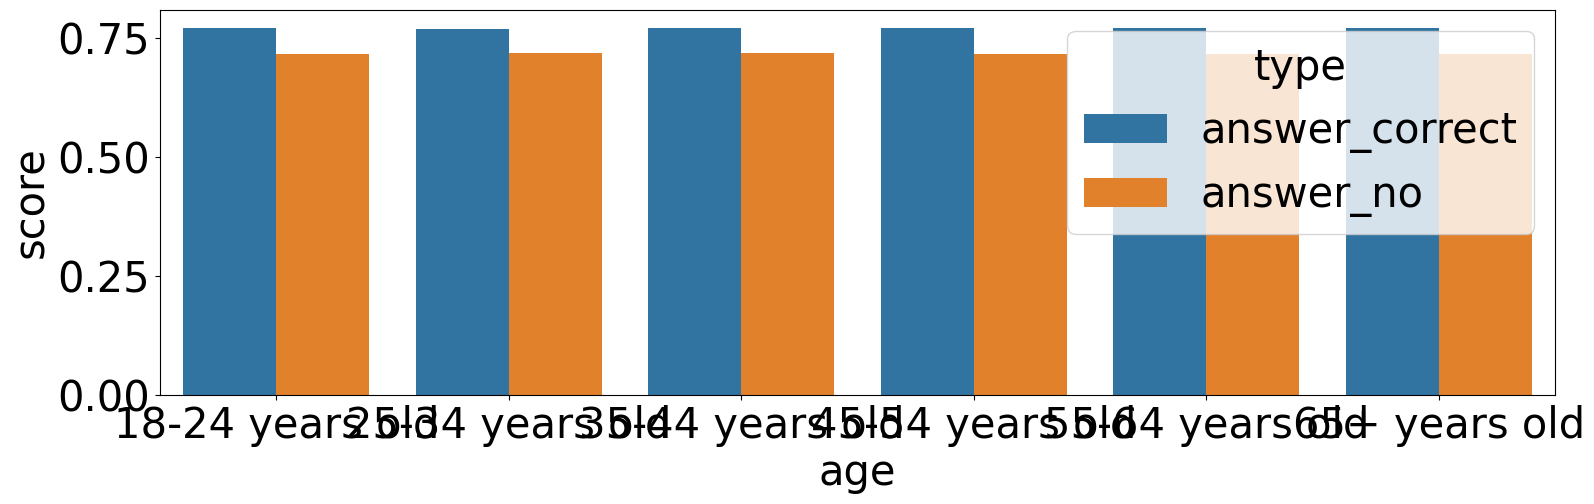

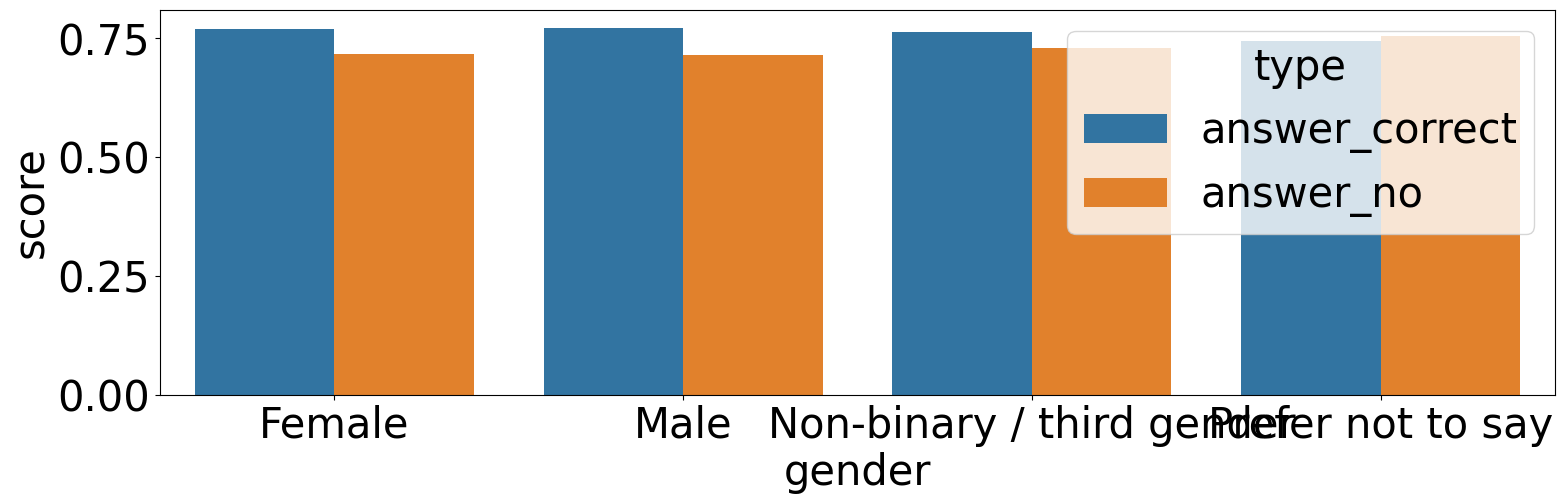

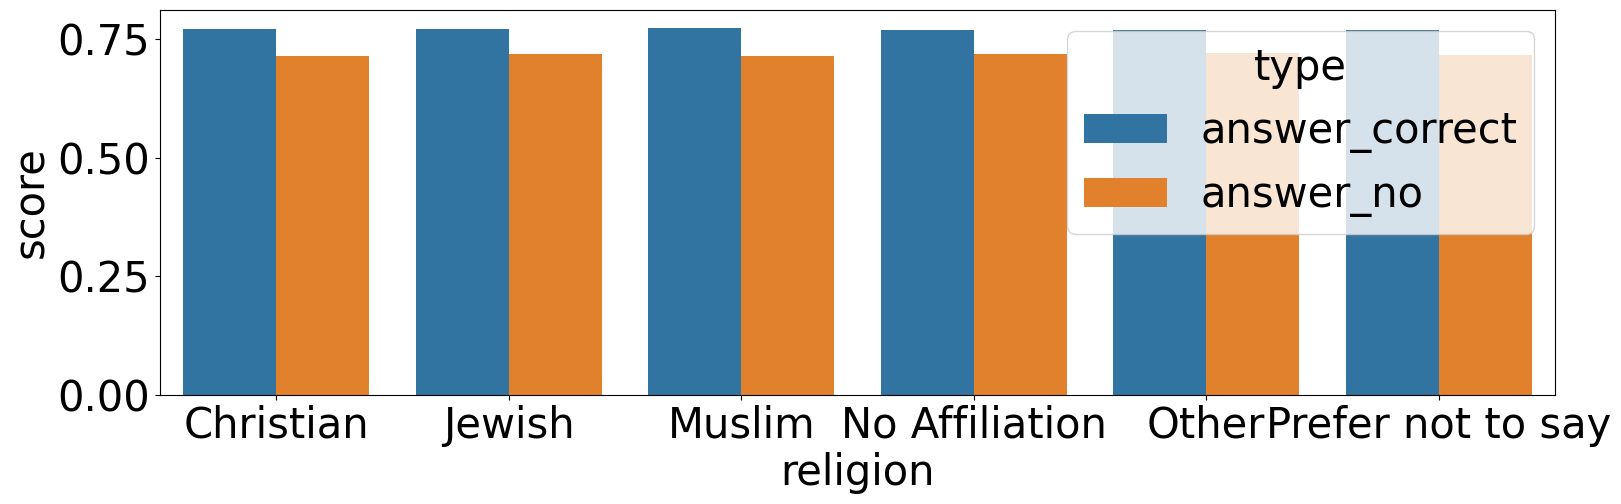

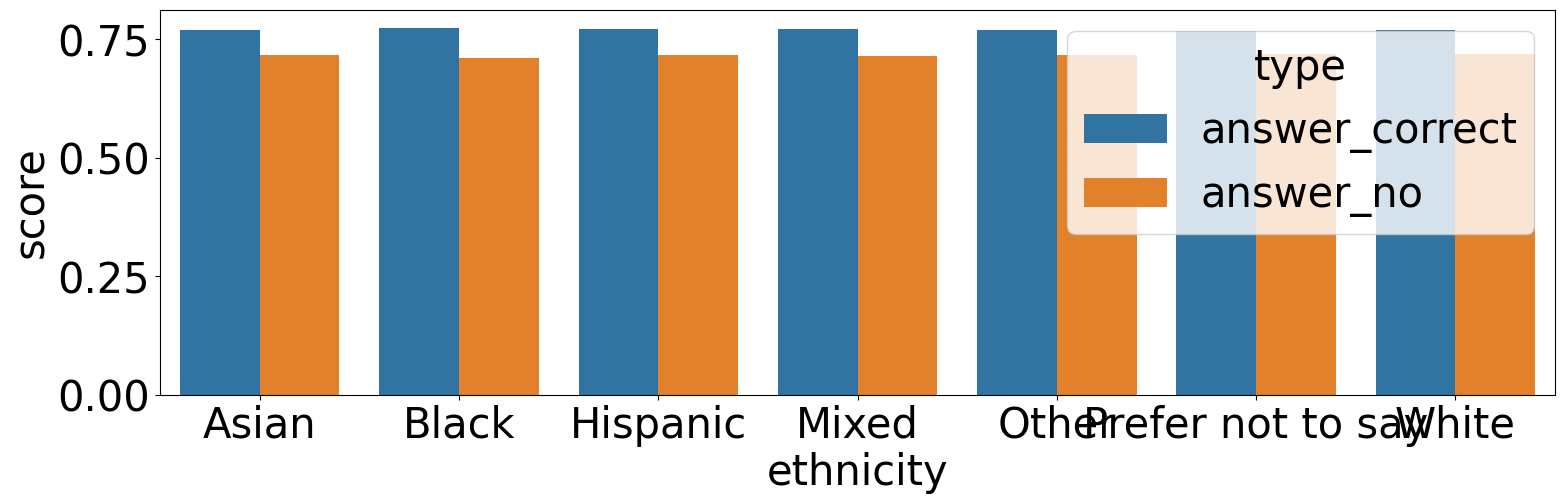

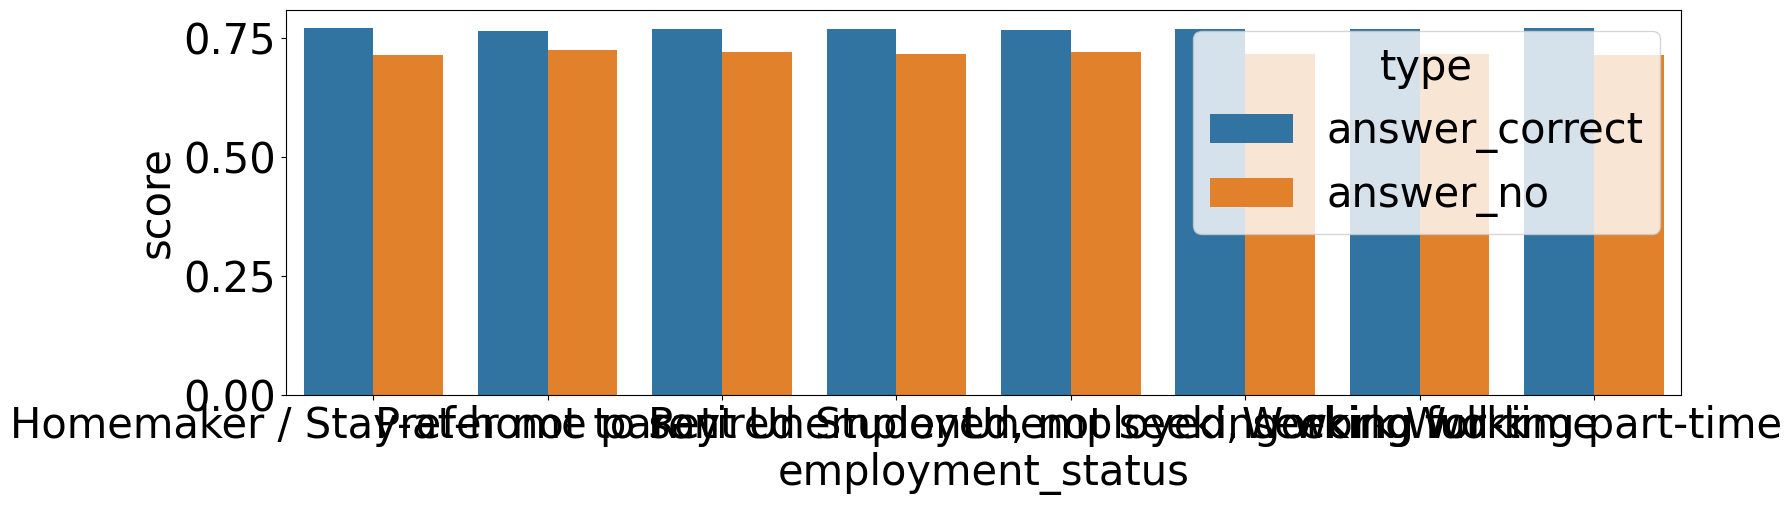

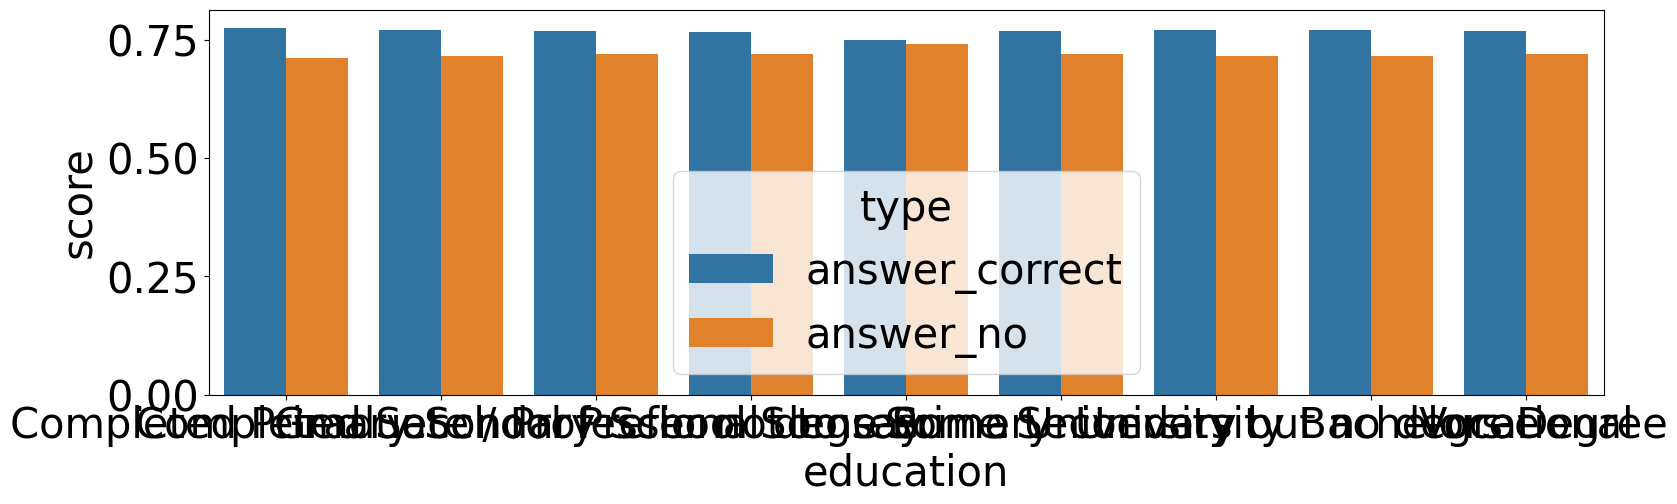

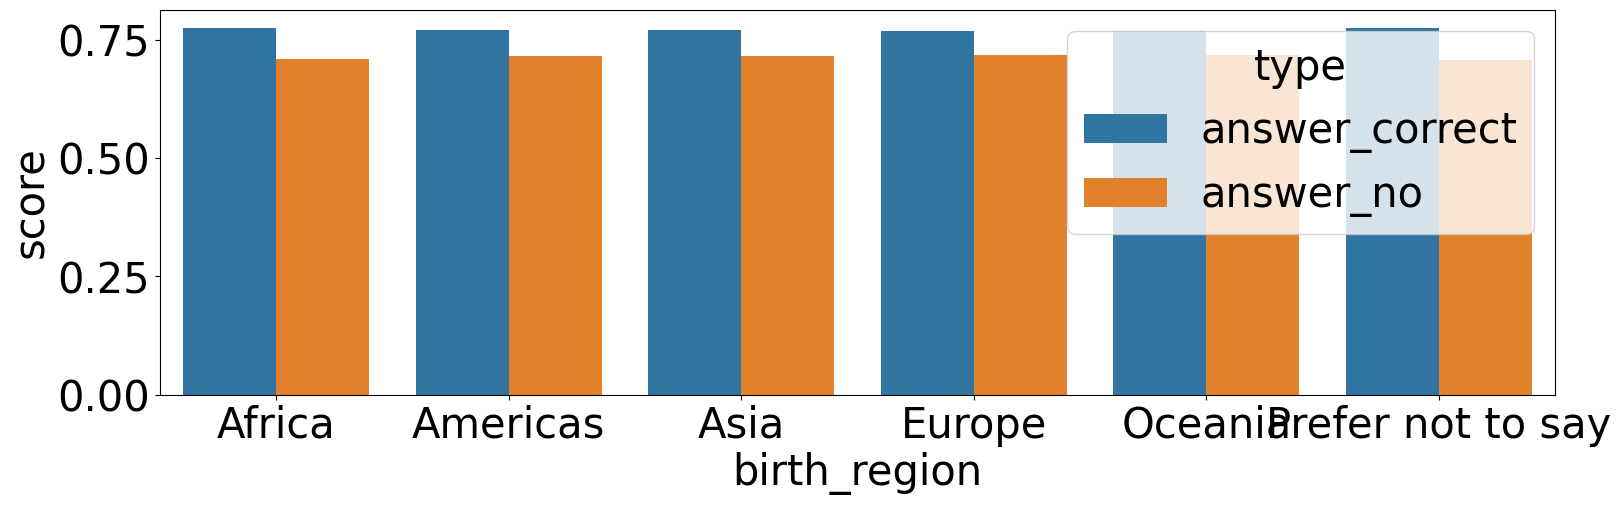

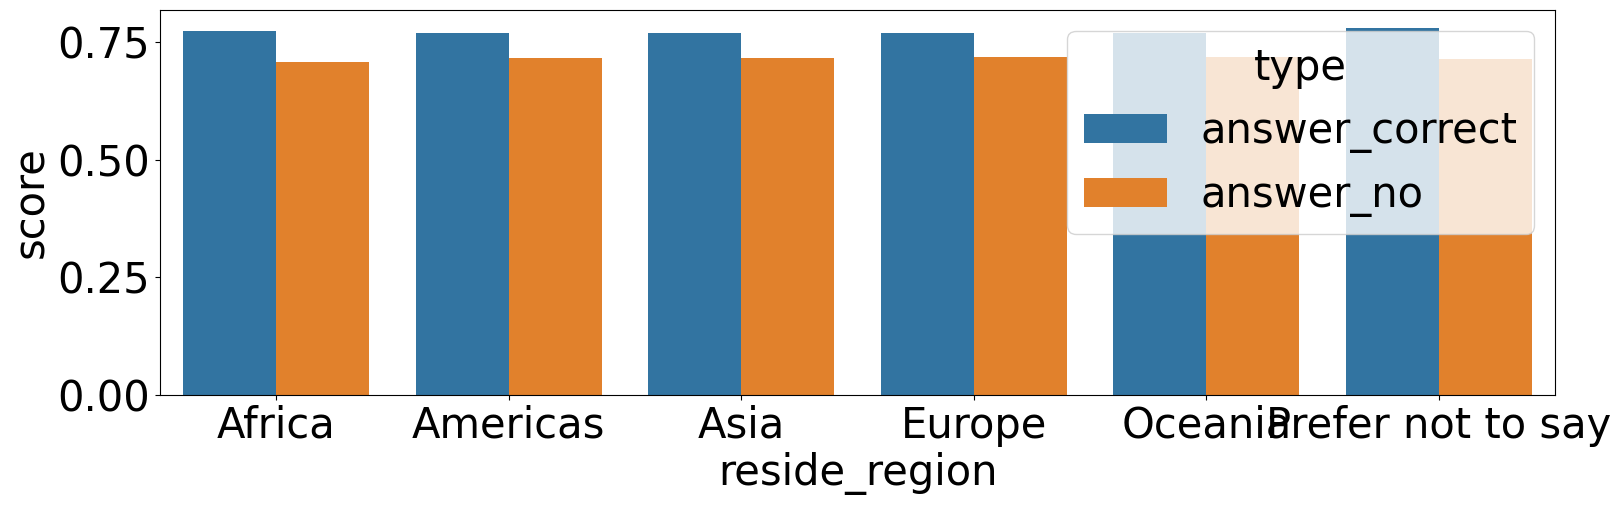

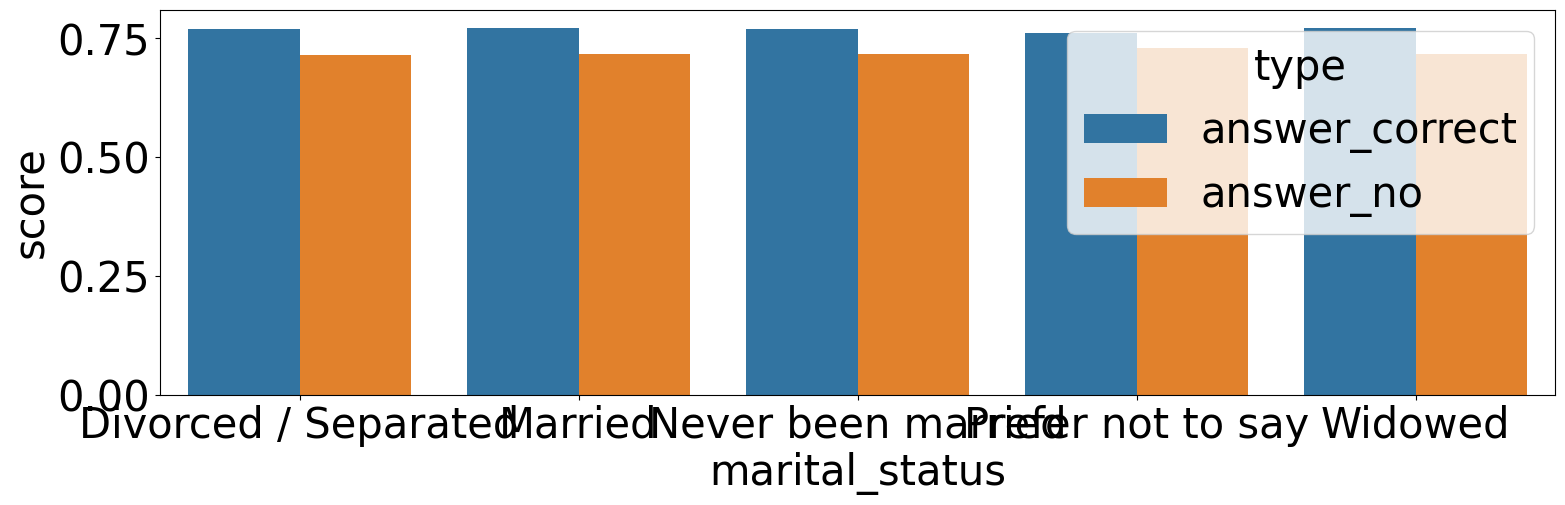

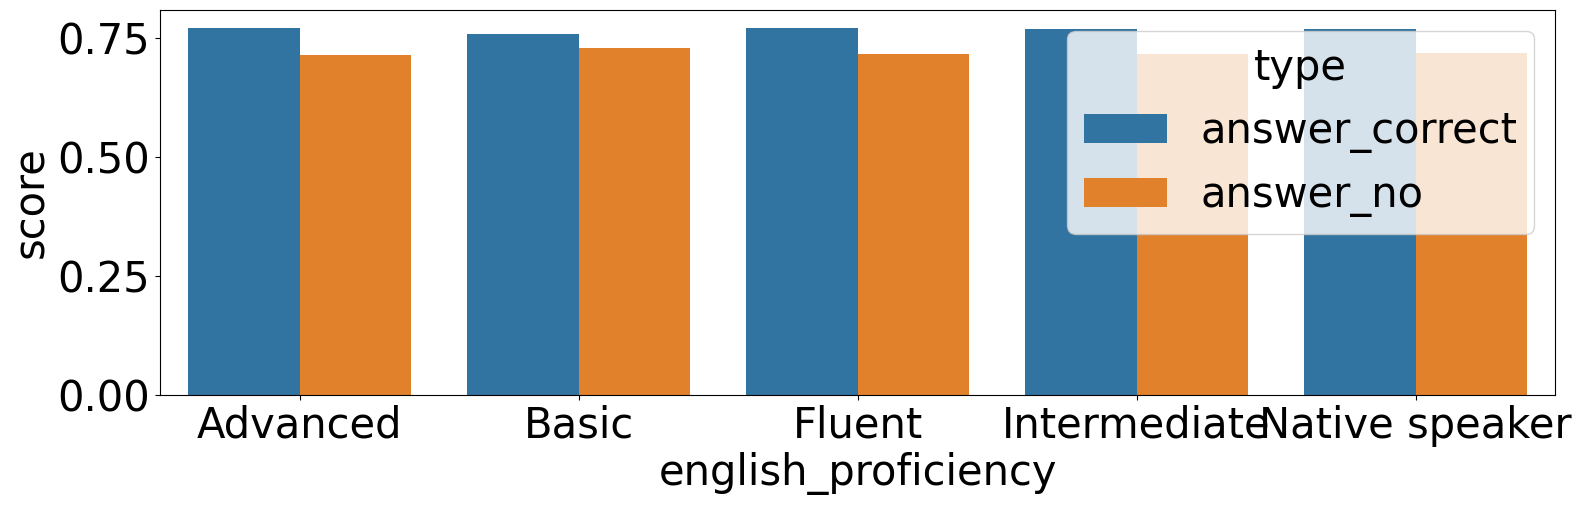

In [72]:
plt.rcParams.update({"font.size": 30})
model_answers = {
    "OLMo": olmo_answers,
}

for demographic in demographics:
    fig, axes = plt.subplots(1, len(model_answers), sharex=False, sharey=True, figsize=(18, 5))
    for i, model in enumerate(model_answers):
        df = model_answers[model].groupby([demographic, "type"])[["score"]].mean().reset_index()
        sns.barplot(
            data=df,
            x=demographic,
            y="score",
            hue="type",
            ax=axes
            #ax=axes[i],
        )

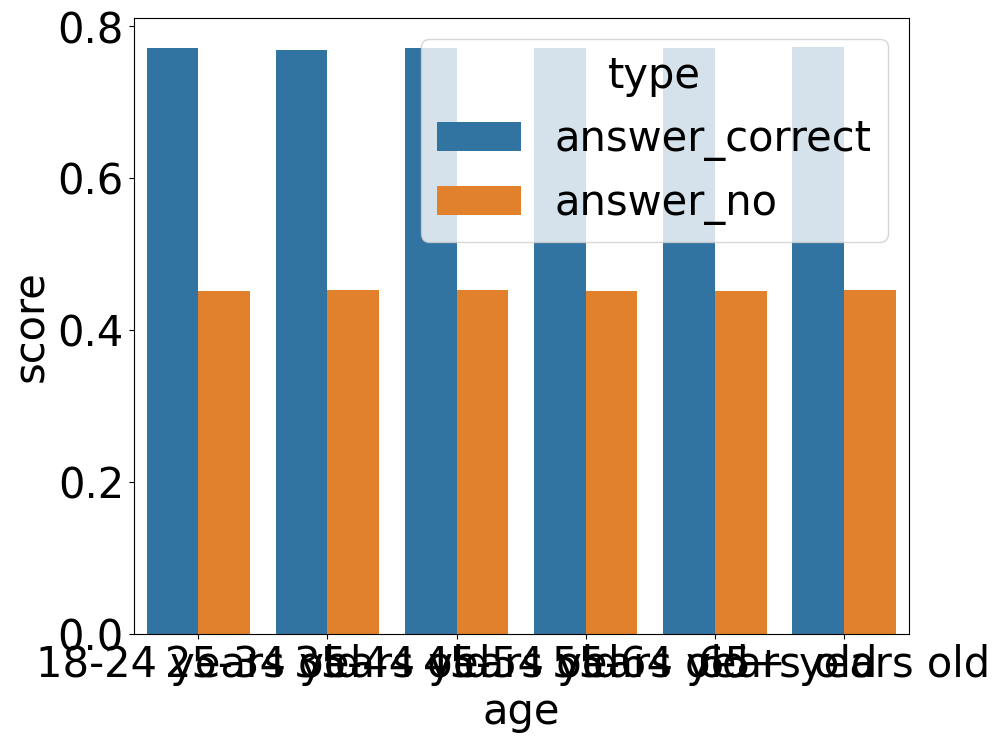

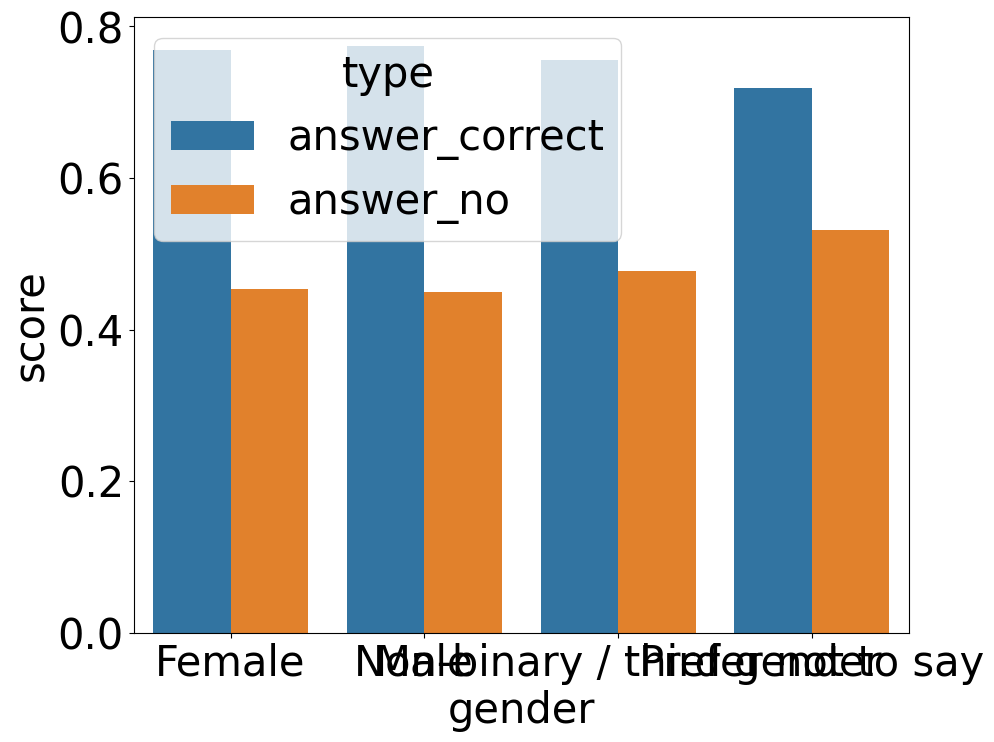

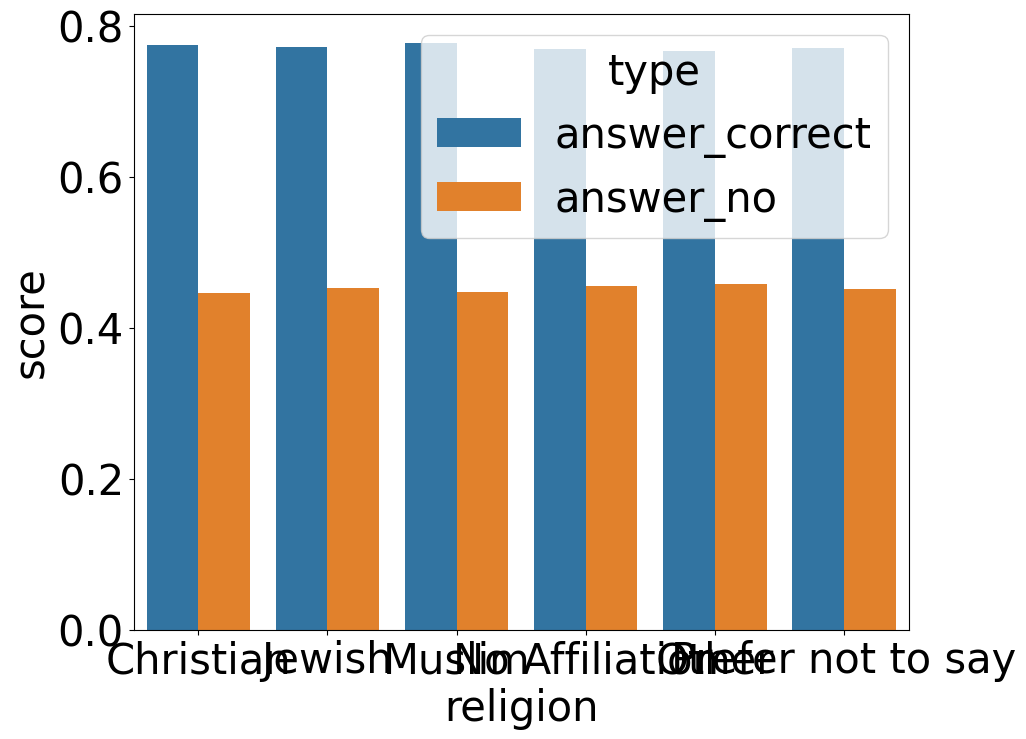

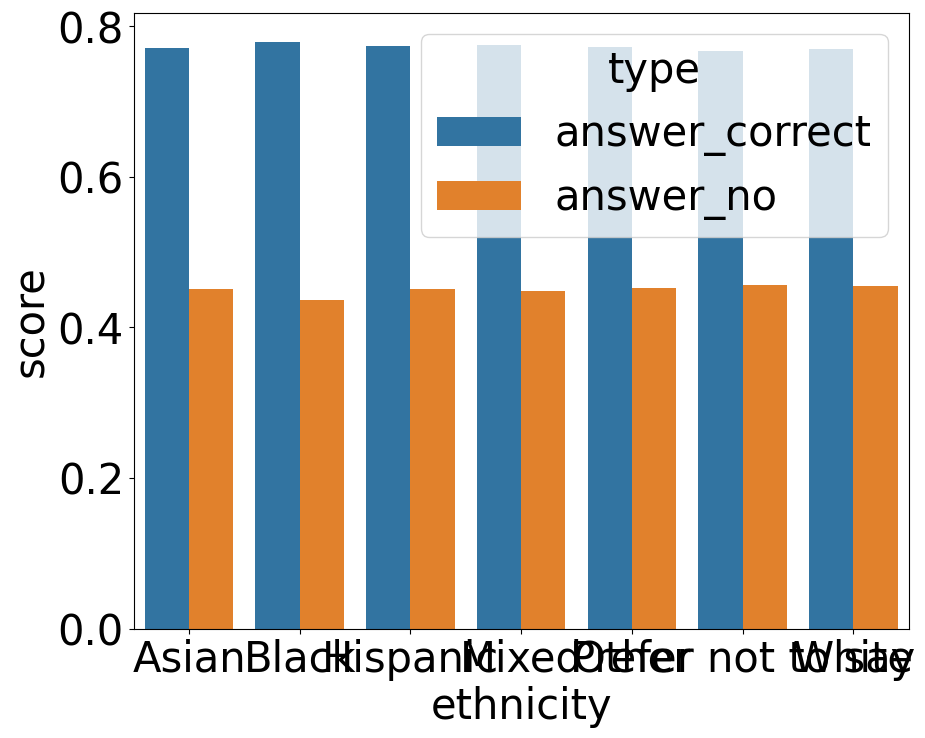

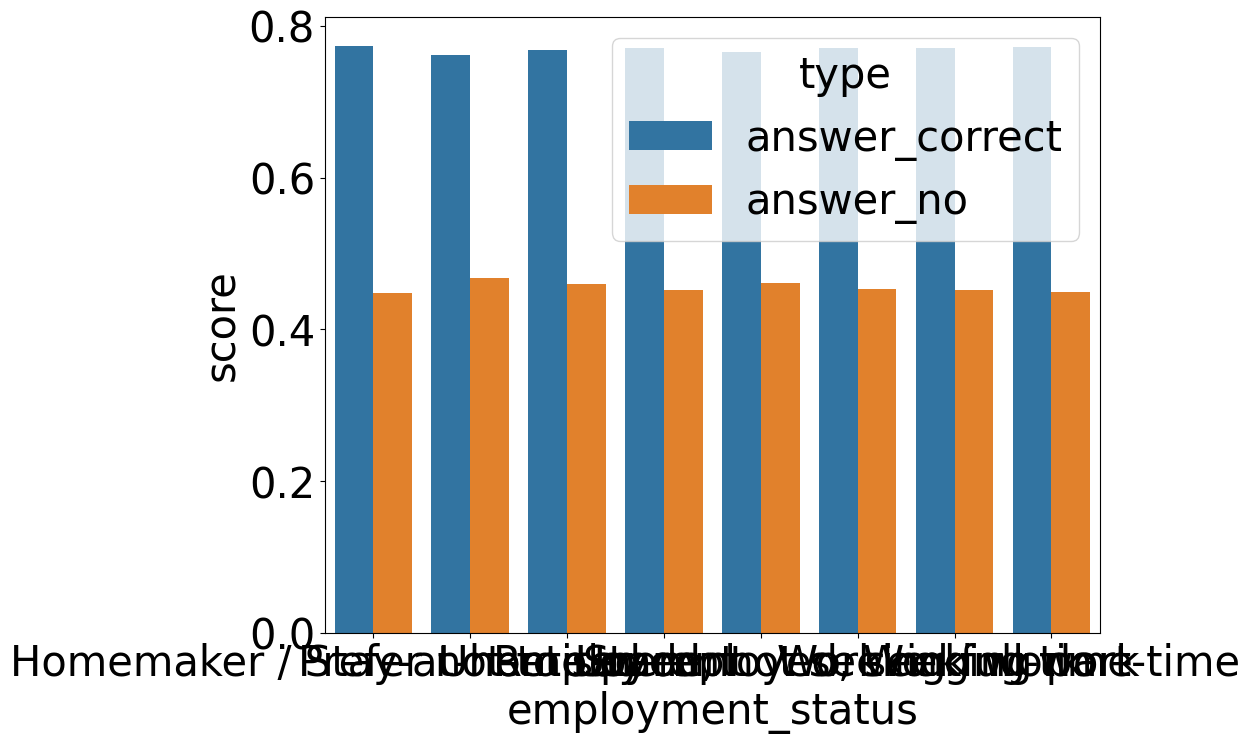

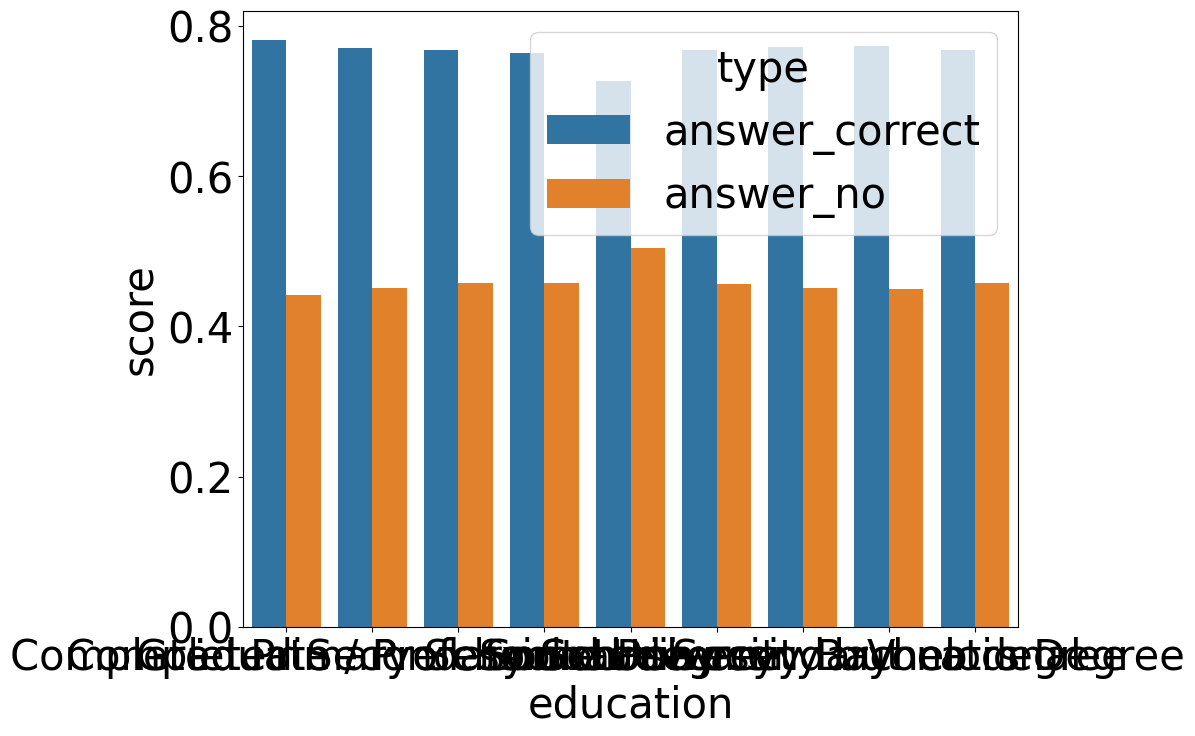

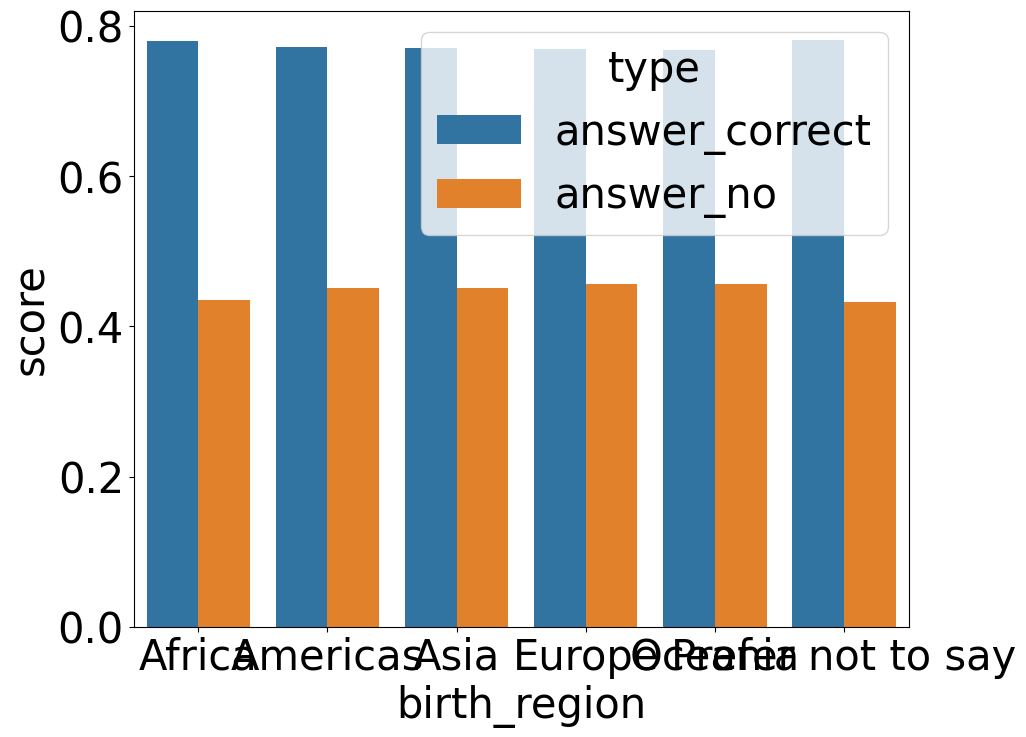

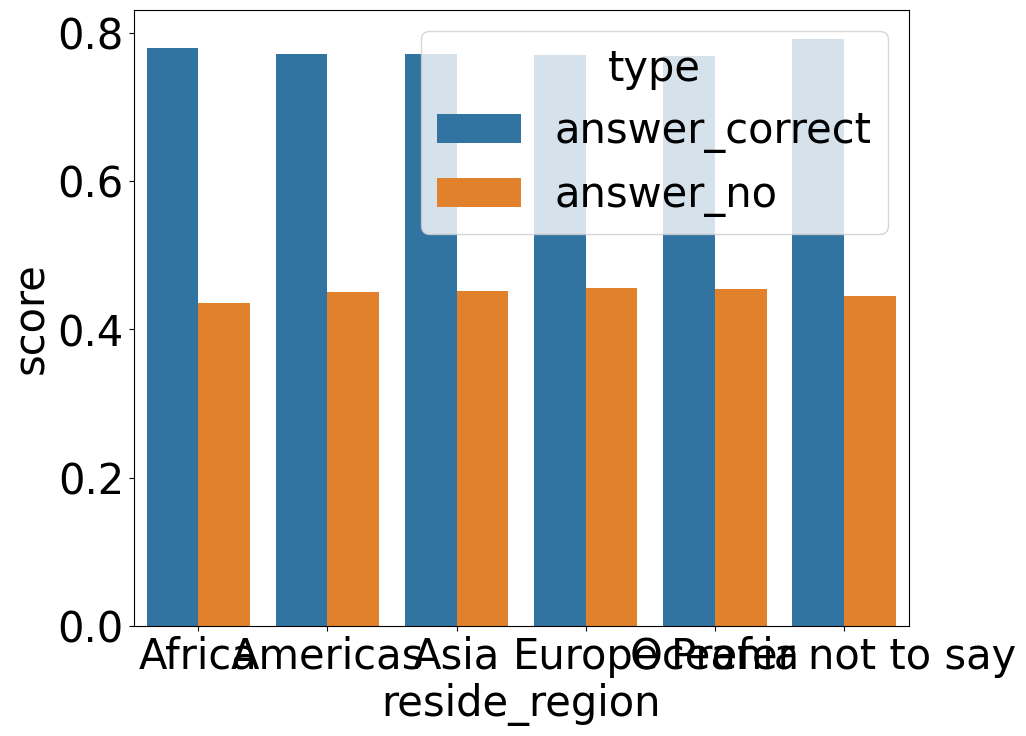

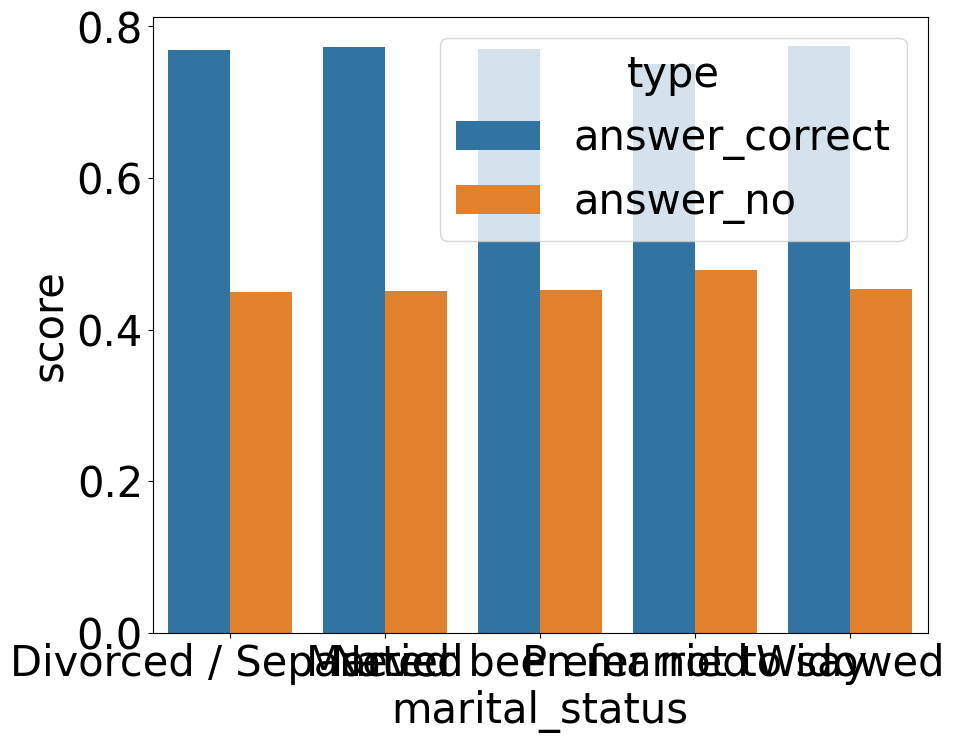

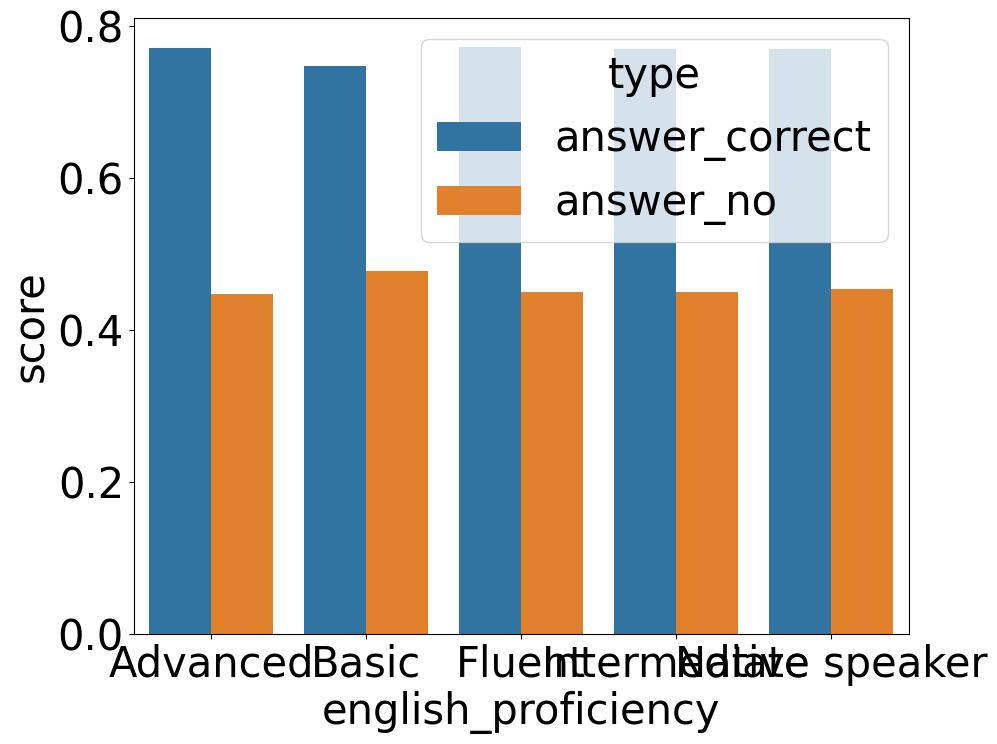

In [152]:
for demographic in demographics:
    fig, axes = plt.subplots(1, len(model_answers), sharex=False, sharey=True, figsize=(8, 12))
    for i, model in enumerate(model_answers):
        df = model_answers[model][model_answers[model]["question"].isin(diff_questions)].groupby([demographic, "type"])[["score"]].mean().reset_index()
        sns.barplot(
            data=df,
            x=demographic,
            y="score",
            hue="type",
            ax=axes
            #ax=axes[i],
        )

In [7]:
def prepare_df(results):
    df = pd.DataFrame(results)
    df = df.T
    df = df.stack()
    df = df.reset_index()
    df = df.rename(columns={"level_0": "demographic", "level_1": "layer"})
    df = pd.concat([df.drop([0], axis=1), df[0].apply(pd.Series)], axis=1)
    f1_weighted = (
        pd.DataFrame(df["f1_weighted"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "f1_weighted"})
    )
    f1_micro = (
        pd.DataFrame(df["f1_micro"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "f1_micro"})
    )
    f1_macro = (
        pd.DataFrame(df["f1_macro"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "f1_macro"})
    )
    acc_balanced = (
        pd.DataFrame(df["balanced_accuracy"].tolist(), columns=["1", "2", "3", "4", "5"])
        .stack()
        .reset_index()
        .rename(columns={"level_1": "cv", 0: "balanced_accuracy"})
    )
    #acc["acc"] = acc["acc"].mul(100)
    df = pd.merge(df, f1_weighted, left_index=True, right_on=["level_0"]).drop(
        columns=["f1_weighted_x"]
    )
    df = pd.merge(df, f1_micro, on=["level_0" ,"cv"]).drop(columns=["f1_micro_x"])
    df = pd.merge(df, f1_macro, on=["level_0" ,"cv"]).drop(columns=["f1_macro_x"])
    df = pd.merge(df, acc_balanced, on=["level_0", "cv"]).drop(columns=["balanced_accuracy_x", "level_0"]).rename(columns={"f1_weighted_y": "f1_weighted", "f1_micro_y": "f1_micro", "f1_macro_y": "f1_macro", "balanced_accuracy_y": "balanced_accuracy"})
    return df

In [5]:
# with open("results/OLMo-2-1124-7B-Instruct_probe_results.pkl", "rb") as infile:
#     olmo_probe = pickle.load(infile)

with open("results/OLMo-2-1124-7B-Instruct_probe_results_mean.pkl", "rb") as infile:
    olmo_probe_mean = pickle.load(infile)

with open("results/OLMo-2-1124-7B-Instruct_probe_results_last.pkl", "rb") as infile:
    olmo_probe_last = pickle.load(infile)

In [8]:
model_results = {
    "OLMo mean": olmo_probe_mean,
    "OLMo last": olmo_probe_last,
}
for model in model_results:
    results = model_results[model]
    df = prepare_df(results)
    model_results[model] = df

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


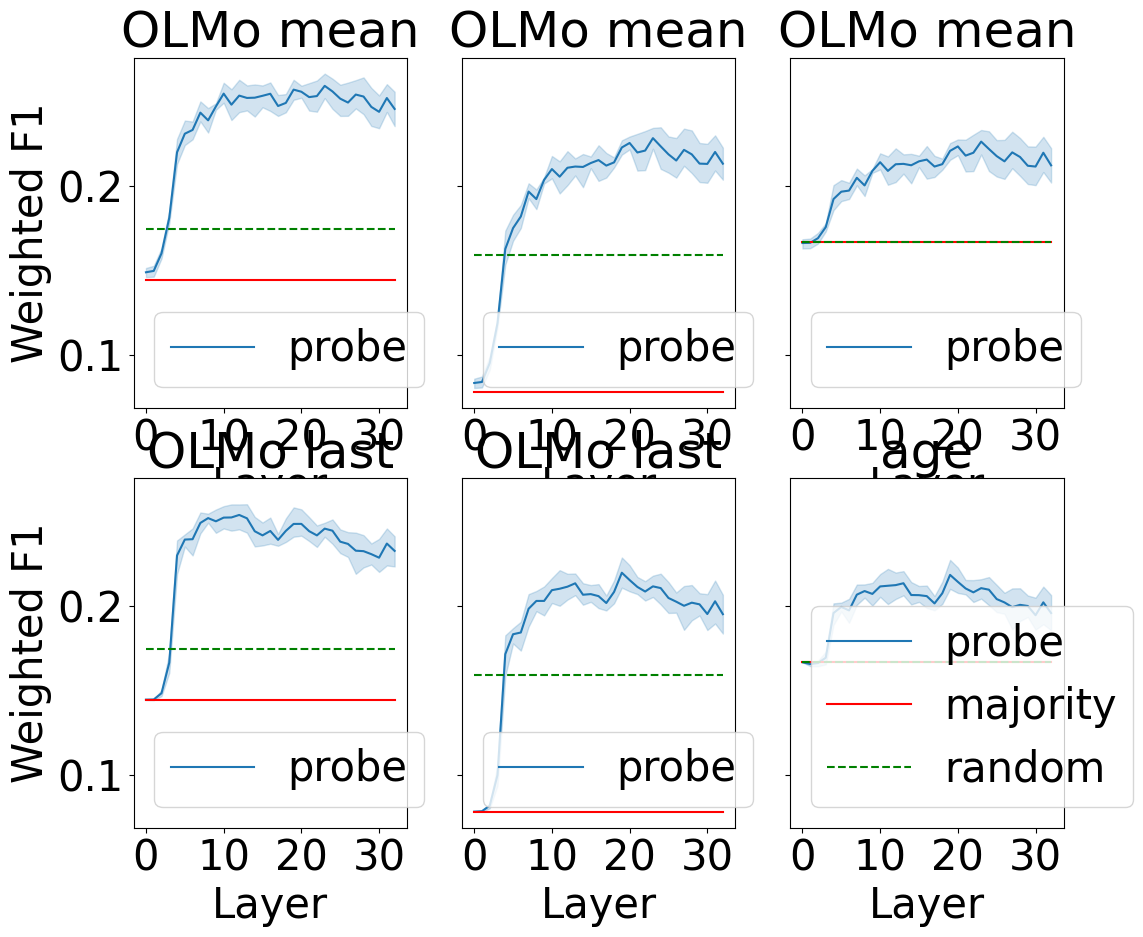

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


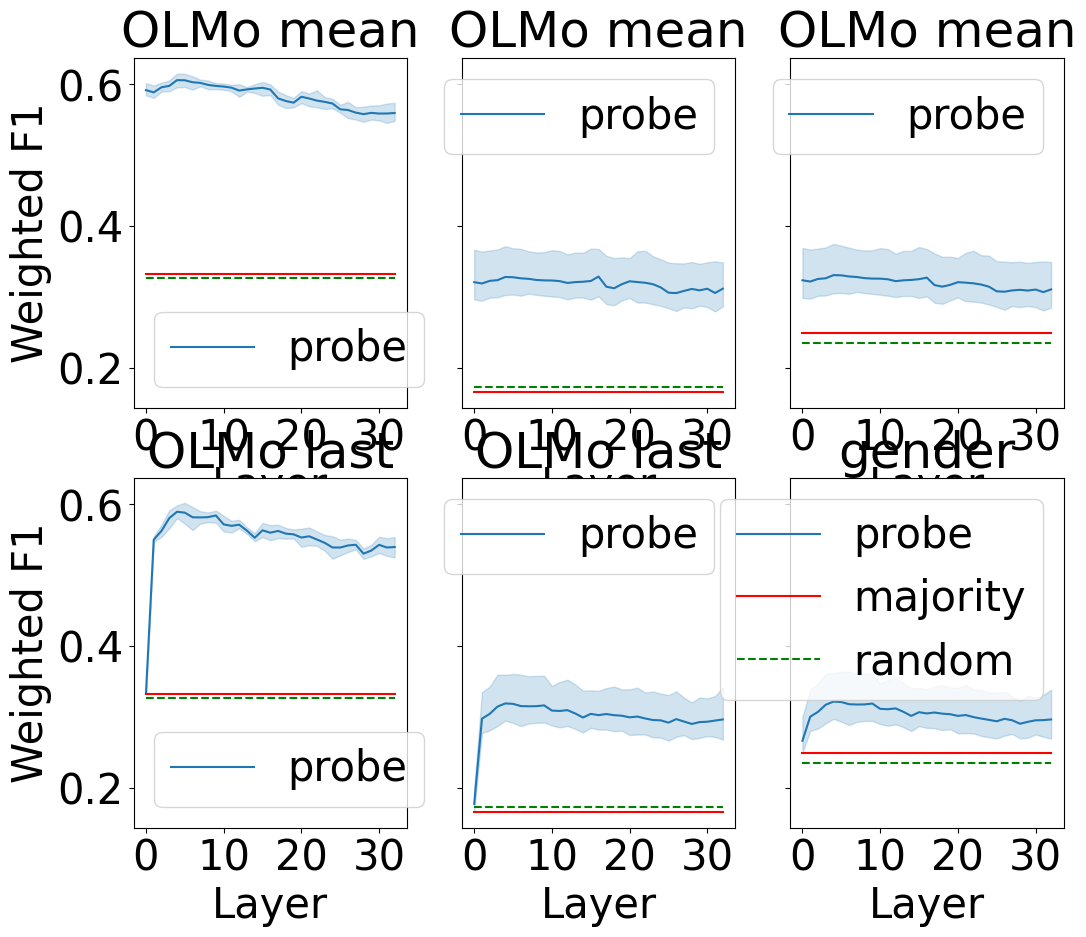

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


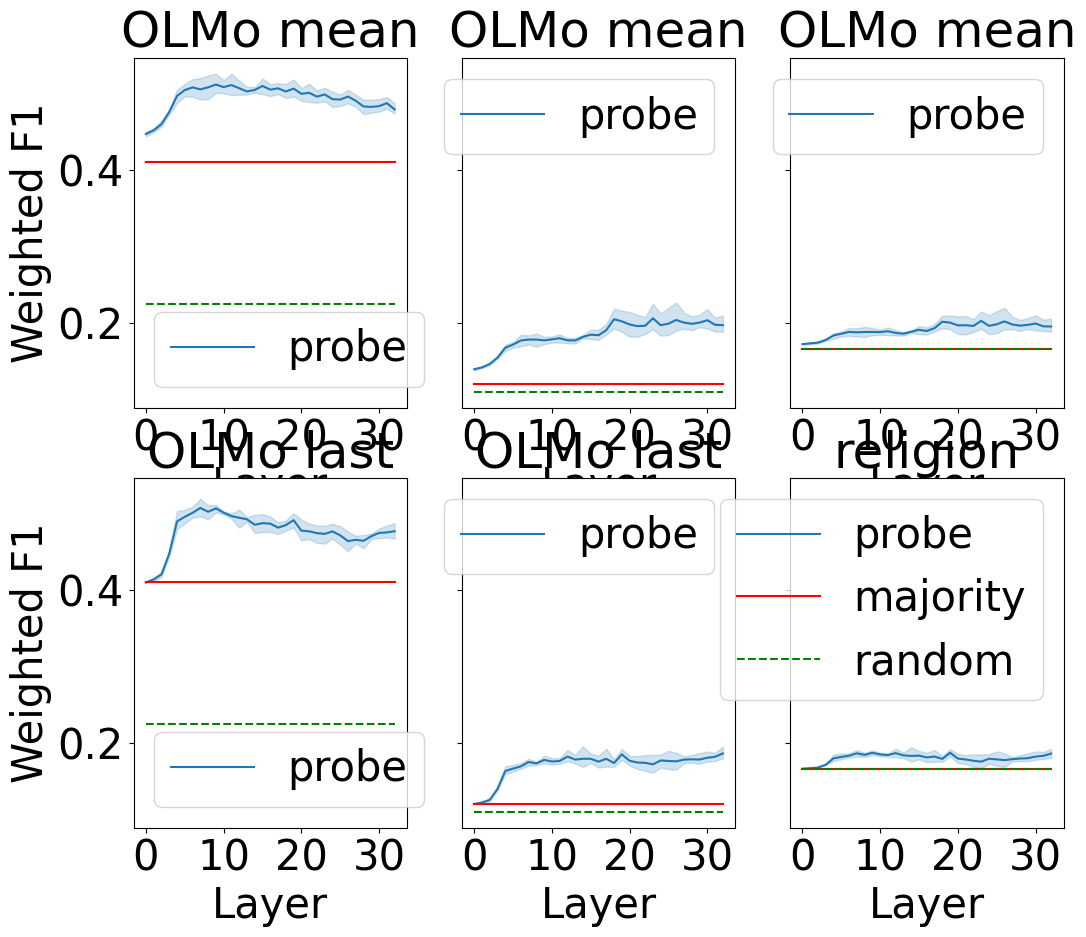

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


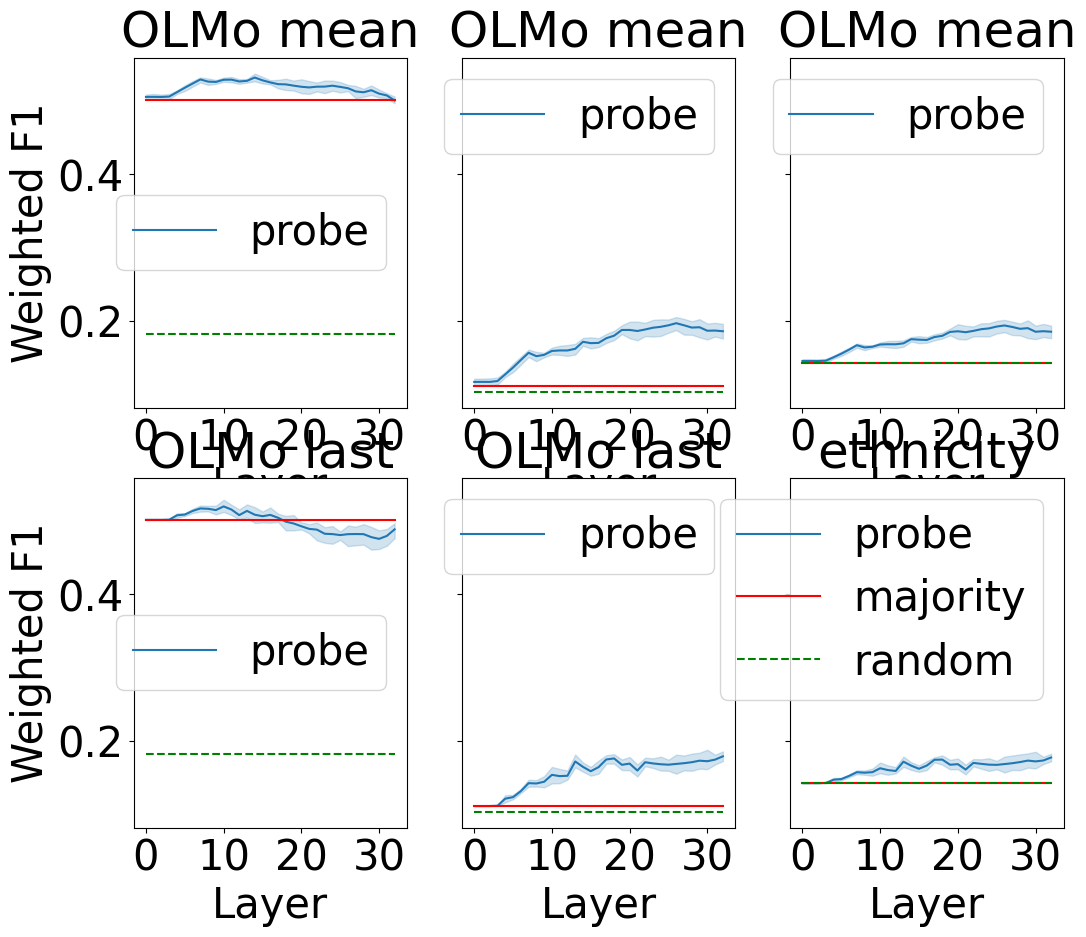

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


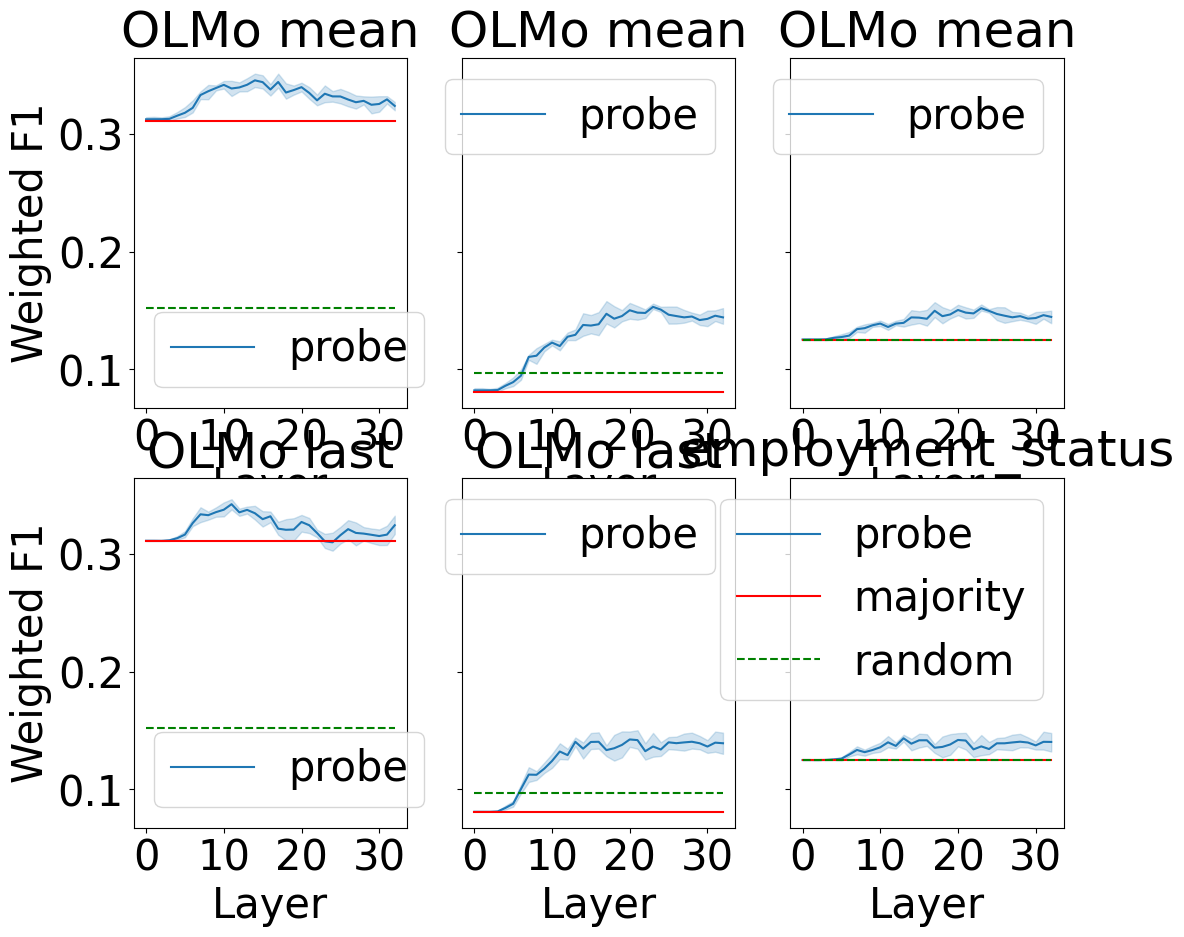

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


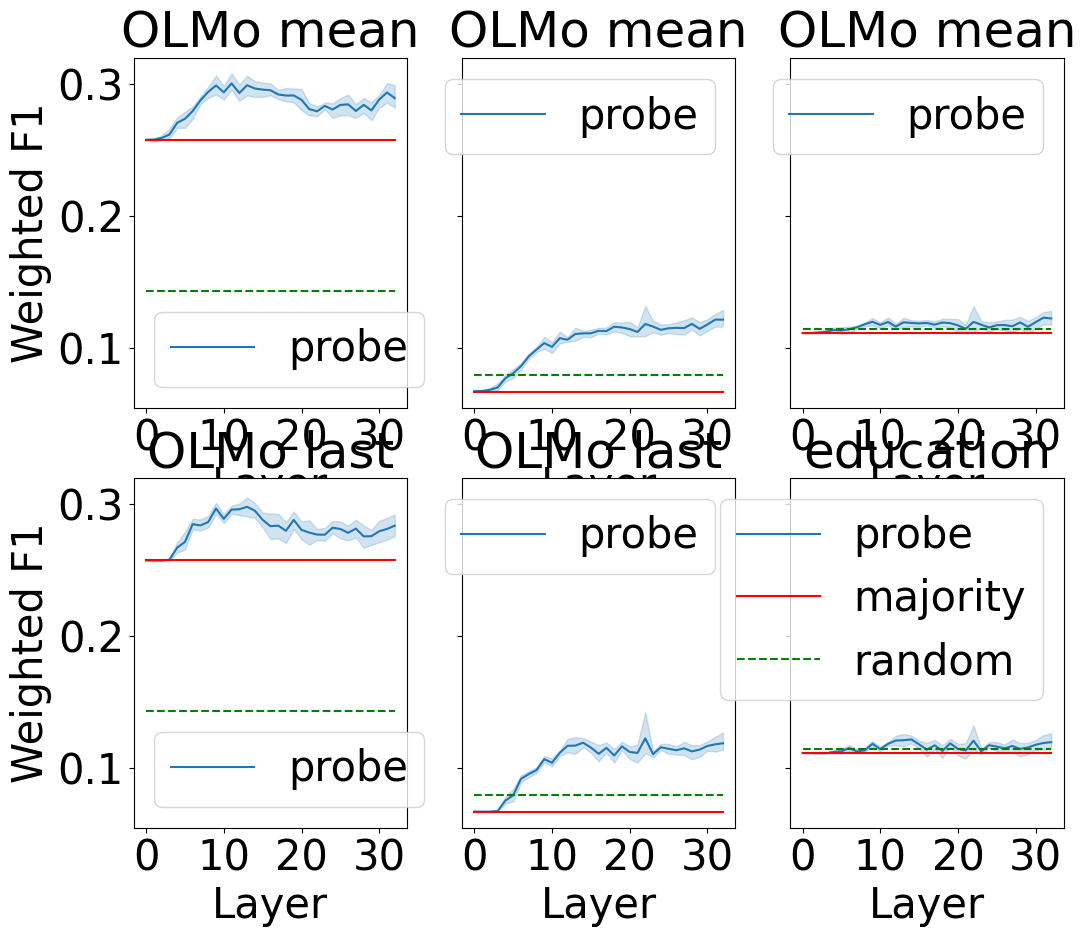

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


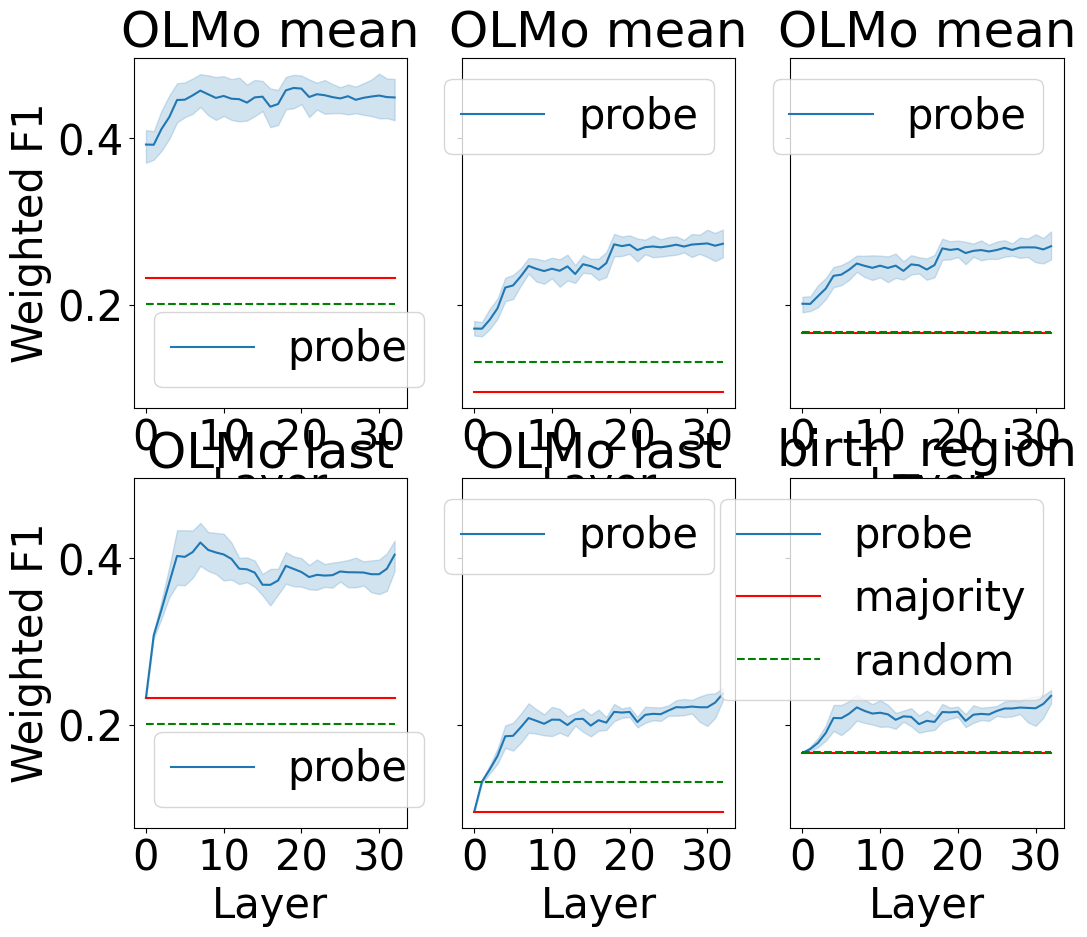

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


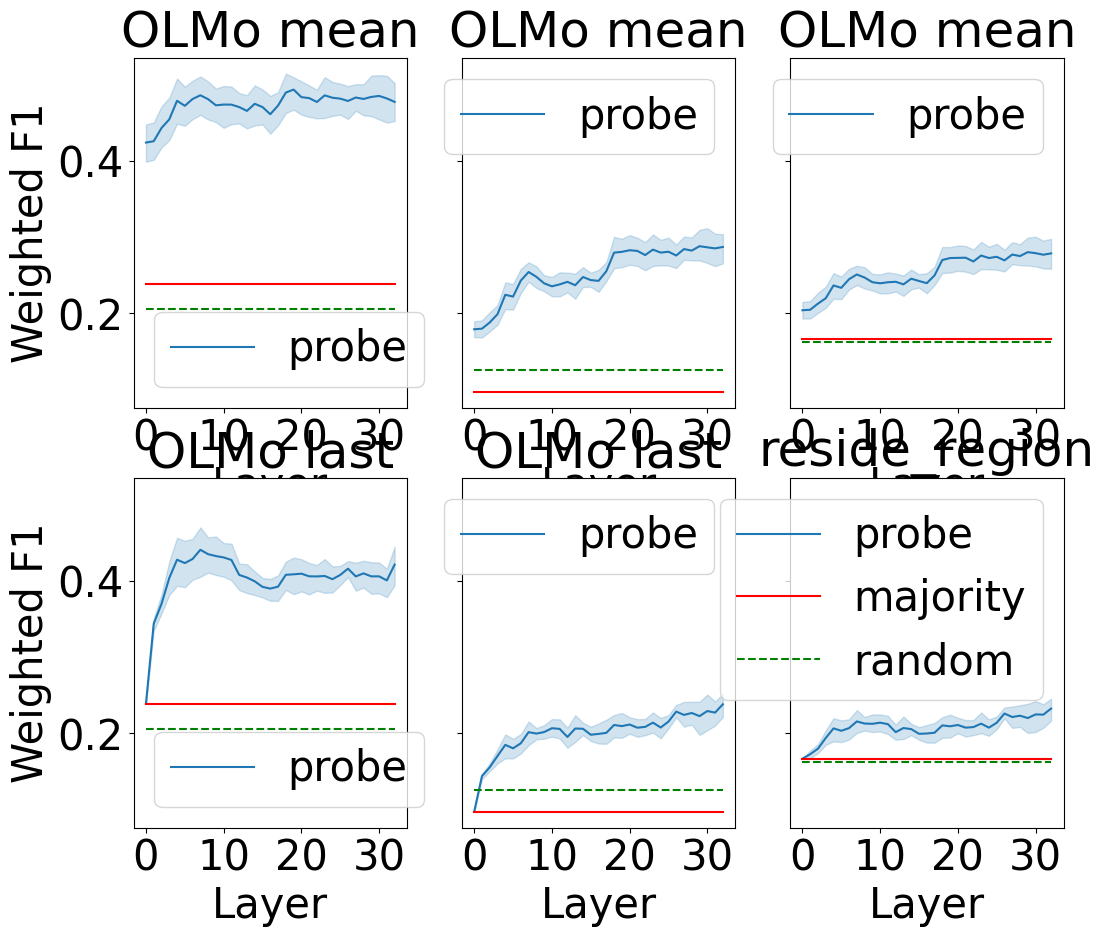

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


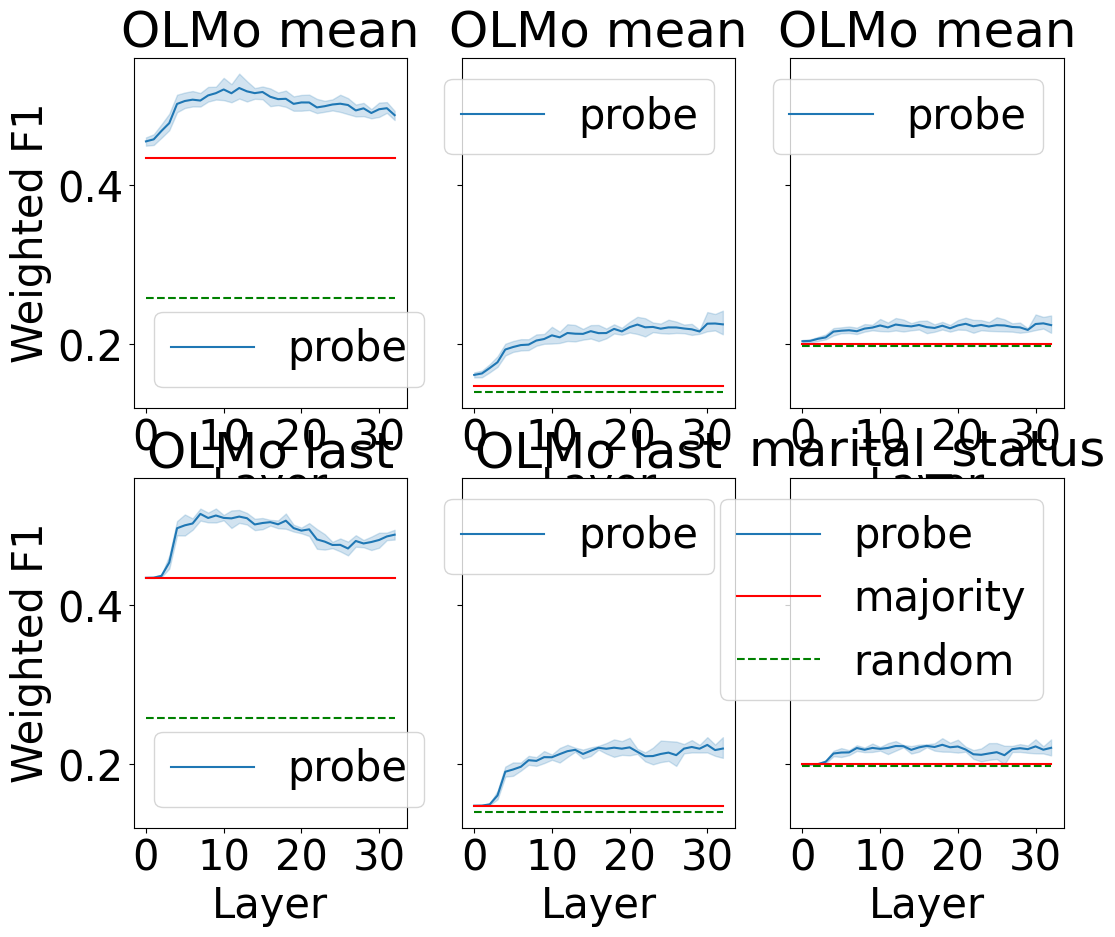

/tmp/ipykernel_114522/4190086627.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


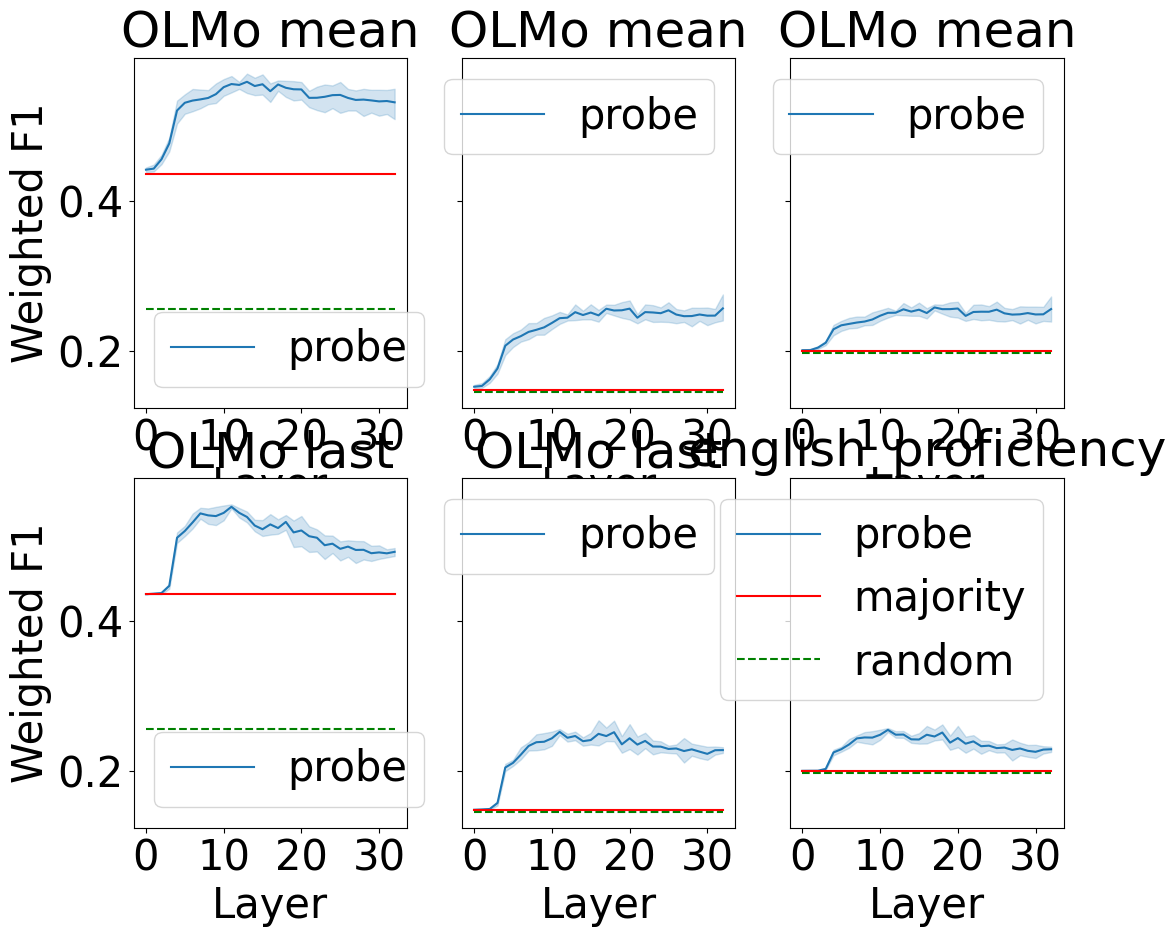

In [9]:
plt.rcParams.update({"font.size": 30})

for demographic in demographics:
    fig, all_axes = plt.subplots(len(model_results), 3, sharex=False, sharey=True, figsize=(12, 10))
    for i, model in enumerate(model_results):
        df = model_results[model]
        axes = all_axes[i]
        sns.lineplot(
            data=df[df["demographic"] == demographic],
            x="layer",
            y="f1_weighted",
            #ax=axes,
            label="probe",
            ax=axes[0],
        )
        axes[0].plot([0,32],[baselines[demographic]["majority_weighted"],baselines[demographic]["majority_weighted"]], color='r', linestyle='-', label="majority")
        axes[0].plot([0,32],[baselines[demographic]["random_weighted"],baselines[demographic]["random_weighted"]], color='g', linestyle='--', label="random")
        # sns.lineplot(
        #     data=df[df["demographic"] == demographic],
        #     x="layer",
        #     y="f1_micro",
        #     #ax=axes,
        #     label="probe",
        #     ax=axes[1],
        # )
        # axes[1].plot([0,32],[baselines[demographic]["majority_micro"],baselines[demographic]["majority_micro"]], color='r', linestyle='-', label="majority")
        # axes[1].plot([0,32],[baselines[demographic]["random_micro"],baselines[demographic]["random_micro"]], color='g', linestyle='--', label="random")
        sns.lineplot(
            data=df[df["demographic"] == demographic],
            x="layer",
            y="f1_macro",
            #ax=axes,
            label="probe",
            ax=axes[1],
        )
        axes[1].plot([0,32],[baselines[demographic]["majority_macro"],baselines[demographic]["majority_macro"]], color='r', linestyle='-', label="majority")
        axes[1].plot([0,32],[baselines[demographic]["random_macro"],baselines[demographic]["random_macro"]], color='g', linestyle='--', label="random")
        sns.lineplot(
            data=df[df["demographic"] == demographic],
            x="layer",
            y="balanced_accuracy",
            #ax=axes,
            label="probe",
            ax=axes[2],
        )
        axes[2].plot([0,32],[baselines[demographic]["majority_balancedacc"],baselines[demographic]["majority_balancedacc"]], color='r', linestyle='-', label="majority")
        axes[2].plot([0,32],[baselines[demographic]["random_balancedacc"],baselines[demographic]["random_balancedacc"]], color='g', linestyle='--', label="random")
        plt.legend(loc="best")
        #plt.ylim(0, 105)
        for ax in axes:
            ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
            ax.set_title(model)
            ax.set_xlabel("Layer")
        axes[0].set_ylabel("Weighted F1")
        #axes[1].set_ylabel("Micro F1")
        axes[1].set_ylabel("Macro F1")
        axes[2].set_ylabel("Balanced accuracy")
    plt.title(demographic)
    plt.show()